# Case Study: Phân tích nhu cầu sản phẩm thời trang trên Tiki

Notebook này phân tích dữ liệu sản phẩm thời trang trên Tiki theo ba câu hỏi nghiên cứu:

**RQ1.** Các nhóm sản phẩm thời trang trên Tiki khác nhau như thế nào về giá bán, rating, số lượt đánh giá, số ảnh, video và số lượng bán?

**RQ2.** Sản phẩm có video có số lượng bán trung bình cao hơn sản phẩm không có video hay không, và sự khác biệt này có thể được giải thích bằng ngẫu nhiên hay không?

**RQ3.** Những đặc trưng như giá bán, giảm giá, đánh giá, số lượng đánh giá, hình ảnh và video có liên quan như thế nào đến nhu cầu sản phẩm, và liệu có thể sử dụng chúng để dự đoán lượng bán hay không?

Cấu trúc notebook đi từ phân tích mô tả, trực quan hóa, lấy mẫu và mô phỏng, kiểm định giả thuyết, bootstrap confidence interval, đến multiple linear regression để dự đoán demand.

# 1. Import thư viện

Ta chỉ dùng `numpy`, `matplotlib`, và thư viện chuẩn Python để đọc CSV. Phần hồi quy được viết bằng các hàm đơn giản để thấy rõ ý tưởng, không dùng thư viện machine learning nâng cao.

In [1]:
from pathlib import Path
import csv
import warnings

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import display, Markdown
except Exception:
    Markdown = None
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


def n_rows(table):
    if not table:
        return 0
    first_col = next(iter(table.values()))
    return len(first_col)


def take_rows(table, selector):
    return {col: values[selector] for col, values in table.items()}


def copy_table(table):
    return {col: values.copy() for col, values in table.items()}


def normalize_scalar(value, precision=3):
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, float):
        if np.isnan(value):
            return ""
        return f"{value:,.{precision}f}"
    if isinstance(value, (int, bool)):
        return str(value)
    return str(value)


def display_table(records, columns=None, max_rows=20, precision=3):
    """Display list-of-dict records as a compact Markdown table without pandas."""
    records = list(records)
    if not records:
        print("(empty table)")
        return

    if columns is None:
        columns = list(records[0].keys())

    shown = records[:max_rows]
    header = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    lines = [header, sep]
    for row in shown:
        values = [normalize_scalar(row.get(col, ""), precision=precision) for col in columns]
        values = [value.replace("|", "\\|").replace("\n", " ") for value in values]
        lines.append("| " + " | ".join(values) + " |")

    if len(records) > max_rows:
        lines.append(f"| ... | {' | '.join([''] * (len(columns) - 1))} |")

    markdown = "\n".join(lines)
    if Markdown is not None:
        display(Markdown(markdown))
    else:
        print(markdown)


def head_records(table, n=5, columns=None):
    if columns is None:
        columns = list(table.keys())
    rows = []
    limit = min(n, n_rows(table))
    for i in range(limit):
        rows.append({col: table[col][i] for col in columns if col in table})
    return rows


def as_float_array(values):
    out = np.empty(len(values), dtype=float)
    for i, value in enumerate(values):
        text = "" if value is None else str(value).strip()
        if text == "" or text.lower() in {"nan", "none", "null", "na"}:
            out[i] = np.nan
            continue
        try:
            out[i] = float(text.replace(",", ""))
        except ValueError:
            out[i] = np.nan
    return out


def as_bool_array(values):
    true_values = {"true", "1", "1.0", "yes", "y", "có", "co"}
    return np.array([
        False if value is None else str(value).strip().lower() in true_values
        for value in values
    ], dtype=bool)


def concat_tables(tables):
    columns = []
    for table in tables:
        for col in table:
            if col not in columns:
                columns.append(col)

    result = {}
    for col in columns:
        parts = []
        for table in tables:
            if col in table:
                parts.append(table[col])
            else:
                parts.append(np.array([""] * n_rows(table), dtype=object))
        result[col] = np.concatenate(parts)
    return result


def read_csv_as_table(path, product_group):
    with path.open("r", encoding="utf-8-sig", newline="") as handle:
        reader = csv.DictReader(handle)
        fieldnames = list(reader.fieldnames or [])
        columns = {field: [] for field in fieldnames}
        columns["product_group"] = []

        for row in reader:
            for field in fieldnames:
                columns[field].append(row.get(field, ""))
            columns["product_group"].append(product_group)

    return {col: np.asarray(values, dtype=object) for col, values in columns.items()}


def unique_preserve_order(values):
    seen = set()
    result = []
    for value in values:
        value = str(value)
        if value not in seen:
            seen.add(value)
            result.append(value)
    return np.asarray(result, dtype=object)


def group_summary(table, group_col, specs, sort_by=None, descending=False):
    keys = np.asarray(table[group_col]).astype(str)
    rows = []
    for group in unique_preserve_order(keys):
        mask = keys == group
        row = {group_col: group}
        for out_name, col, func in specs:
            row[out_name] = func(table[col][mask])
        rows.append(row)

    if sort_by is not None:
        rows = sorted(rows, key=lambda row: row[sort_by], reverse=descending)
    return rows


# 2. Đọc dữ liệu và tổ chức dưới dạng bảng

Trong bảng dữ liệu:

- Mỗi dòng là một sản phẩm trên Tiki.
- Mỗi cột là một biến, ví dụ: giá bán, rating, số review, số ảnh, có video hay không và số lượng bán.

Sáu file CSV được gộp lại thành một bảng lớn. Ta thêm cột `product_group` để biết sản phẩm đến từ nhóm nào.

In [2]:
DATA_DIR = Path.home() / "Downloads"

files = {
    "Backpacks/Suitcases": DATA_DIR / "vietnamese_tiki_products_backpacks_suitcases_FIXED_UTF8_BOM (1).csv",
    "Fashion Accessories": DATA_DIR / "vietnamese_tiki_products_fashion_accessories_FIXED_UTF8_BOM.csv",
    "Men Bags": DATA_DIR / "vietnamese_tiki_products_men_bags_FIXED_UTF8_BOM.csv",
    "Men Shoes": DATA_DIR / "vietnamese_tiki_products_men_shoes_FIXED_UTF8_BOM.csv",
    "Women Bags": DATA_DIR / "vietnamese_tiki_products_women_bags_FIXED_UTF8_BOM.csv",
    "Women Shoes": DATA_DIR / "vietnamese_tiki_products_women_shoes_FIXED_UTF8_BOM.csv",
}

missing = [str(path) for path in files.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Không tìm thấy các file:\n" + "\n".join(missing))

tables = []
for group, path in files.items():
    one_table = read_csv_as_table(path, product_group=group)
    tables.append(one_table)

raw_products = concat_tables(tables)

print("Kích thước bảng gốc:", (n_rows(raw_products), len(raw_products)))
display_table(head_records(raw_products, 3), max_rows=3)


Kích thước bảng gốc: (41603, 20)


|  | id | name | description | original_price | price | fulfillment_type | brand | review_count | rating_average | favourite_count | pay_later | current_seller | date_created | number_of_images | vnd_cashback | has_video | category | quantity_sold | product_group |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | 179731375 | Balo nữ da dầy thời trang unisex màu sắc tươi sáng TA63 |   Balo nữ da dầy thời trang unisex màu sắc tươi sáng TA63   Chào mừng bạn đến với cửa hàng của tôi   Sản phẩm tại cửa hàng sẽ được kiểm tra kỹ càng trước khi xuất xưởng, các bạn cứ yên tâm mua hàng... | 14250 | 14250 | dropship | OEM | 0 | 0.0 | 0 | False | Thiên Ân Balo | 488 | 10 | 0 | False | Balo nữ | 0 | Backpacks/Suitcases |
| 1 | 249221065 | Ví da đựng thẻ ngân hàng (7 màu) - 9205 |      ... | 10260 | 10260 | dropship | OEM | 0 | 0.0 | 0 | False | SHOP THỜI TRANG 2N | 166 | 2 | 0 | False | Root | 0 | Backpacks/Suitcases |
| 2 | 102862196 |  Balo nam nữ thời trang họa tiết bò sữa kiểu mới size mini, đôc đáo hàng chất lượng style kitishop |        Balo họa tiết bò sữa thời trang cho nam và nữ kiểu mới vừa a4   LÀ NHÀ SẢN XUẤT SHOP CAM KẾT:   -LUÔN CÓ SỰ CẢI TIẾN VỀ SẢN PHẨM,ĐẢM BẢO XU THẾ THỊ TRƯỜNG 1 CÁCH SỚM NHẤT   Balo giá rẻ h... | 19999 | 19999 | dropship | OEM | 0 | 0.0 | 0 | False | Xưởng may balo Đà Nẵng | 831 | 5 | 0 | False | Root | 0 | Backpacks/Suitcases |

In [3]:
group_file_summary = group_summary(
    raw_products,
    "product_group",
    [
        ("rows", "id", len),
        ("unique_ids", "id", lambda values: len(np.unique(values.astype(str)))),
    ],
)
for row in group_file_summary:
    row["duplicate_id_rows"] = row["rows"] - row["unique_ids"]

display_table(group_file_summary, columns=["product_group", "rows", "unique_ids", "duplicate_id_rows"])
print("Các cột trong bảng:")
print(list(raw_products.keys()))


| product_group | rows | unique_ids | duplicate_id_rows |
| --- | --- | --- | --- |
| Backpacks/Suitcases | 5361 | 5359 | 2 |
| Fashion Accessories | 16019 | 16005 | 14 |
| Men Bags | 4234 | 4227 | 7 |
| Men Shoes | 5745 | 5744 | 1 |
| Women Bags | 4325 | 4324 | 1 |
| Women Shoes | 5919 | 5917 | 2 |

Các cột trong bảng:
['', 'id', 'name', 'description', 'original_price', 'price', 'fulfillment_type', 'brand', 'review_count', 'rating_average', 'favourite_count', 'pay_later', 'current_seller', 'date_created', 'number_of_images', 'vnd_cashback', 'has_video', 'category', 'quantity_sold', 'product_group']


# 3. Làm sạch dữ liệu và tạo biến mới

Ta thực hiện các thao tác bảng cơ bản:

- Xóa cột index thừa.
- Chuyển các cột số sang dạng numeric.
- Lọc các dòng thiếu dữ liệu quan trọng.
- Loại các dòng có giá trị không hợp lệ.
- Loại sản phẩm trùng `id`.
- Tạo biến mới như `discount_rate`, các biến log và `high_demand`.

Vì `quantity_sold` và `price` thường lệch phải, ta dùng thêm `log_quantity_sold` và `log_price` để quan sát xu hướng rõ hơn.

In [4]:
products = copy_table(raw_products)

# Bỏ cột index thừa nếu có.
index_cols = [
    col for col in products.keys()
    if str(col).startswith("Unnamed") or str(col).strip() == ""
]
for col in index_cols:
    products.pop(col, None)

numeric_cols = [
    "original_price", "price", "review_count", "rating_average",
    "favourite_count", "number_of_images", "vnd_cashback",
    "quantity_sold"
]
for col in numeric_cols:
    if col in products:
        products[col] = as_float_array(products[col])

if "favourite_count" not in products:
    products["favourite_count"] = np.zeros(n_rows(products), dtype=float)

products["has_video"] = as_bool_array(products["has_video"])
products["has_video_int"] = products["has_video"].astype(int)

ids = products["id"].astype(str)
_, first_indices = np.unique(ids, return_index=True)
keep_first = np.zeros(n_rows(products), dtype=bool)
keep_first[first_indices] = True
duplicate_count = int(np.sum(~keep_first))
products = take_rows(products, keep_first)

important_cols = [
    "price", "original_price", "review_count", "rating_average",
    "number_of_images", "quantity_sold"
]
valid_mask = np.ones(n_rows(products), dtype=bool)
for col in important_cols:
    valid_mask &= np.isfinite(products[col])

valid_mask &= (
    (products["price"] >= 0)
    & (products["original_price"] > 0)
    & (products["review_count"] >= 0)
    & (products["rating_average"] >= 0)
    & (products["number_of_images"] >= 0)
    & (products["quantity_sold"] >= 0)
)
products = take_rows(products, valid_mask)

products["discount_rate"] = np.clip(
    (products["original_price"] - products["price"]) / products["original_price"],
    0,
    1,
)

products["log_price"] = np.log1p(products["price"])
products["log_review_count"] = np.log1p(products["review_count"])
products["log_quantity_sold"] = np.log1p(products["quantity_sold"])

# High-demand được định nghĩa là nhóm top 25% theo quantity_sold.
high_demand_cutoff = np.quantile(products["quantity_sold"], 0.75)
products["high_demand"] = (products["quantity_sold"] >= high_demand_cutoff).astype(int)

print("Số dòng ban đầu:", n_rows(raw_products))
print("Số dòng trùng id đã bỏ:", duplicate_count)
print("Số dòng sau làm sạch:", n_rows(products))
print("Ngưỡng high-demand:", high_demand_cutoff)

display_table(head_records(products, 5, [
    "product_group", "name", "price", "original_price", "discount_rate",
    "rating_average", "review_count", "number_of_images", "has_video",
    "quantity_sold", "high_demand"
]))


Số dòng ban đầu: 41603
Số dòng trùng id đã bỏ: 27
Số dòng sau làm sạch: 41575
Ngưỡng high-demand: 5.0


| product_group | name | price | original_price | discount_rate | rating_average | review_count | number_of_images | has_video | quantity_sold | high_demand |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Backpacks/Suitcases | Balo nữ da dầy thời trang unisex màu sắc tươi sáng TA63 | 14,250.000 | 14,250.000 | 0.000 | 0.000 | 0.000 | 10.000 | False | 0.000 | 0 |
| Backpacks/Suitcases | Ví da đựng thẻ ngân hàng (7 màu) - 9205 | 10,260.000 | 10,260.000 | 0.000 | 0.000 | 0.000 | 2.000 | False | 0.000 | 0 |
| Backpacks/Suitcases |  Balo nam nữ thời trang họa tiết bò sữa kiểu mới size mini, đôc đáo hàng chất lượng style kitishop | 19,999.000 | 19,999.000 | 0.000 | 0.000 | 0.000 | 5.000 | False | 0.000 | 0 |
| Backpacks/Suitcases | Vải nhũ bóng simili chống thấm may túi ví balo giày dép | 30,000.000 | 30,000.000 | 0.000 | 0.000 | 0.000 | 4.000 | False | 0.000 | 0 |
| Backpacks/Suitcases |  Combo balo vừa a4 và túi tote thời trang kiểu mới giá siêu rẻ của KiTiShop | 29,000.000 | 29,000.000 | 0.000 | 0.000 | 0.000 | 5.000 | False | 0.000 | 0 |

In [5]:
basic_summary = [
    {"Statistic": "Số sản phẩm sau làm sạch", "Value": n_rows(products)},
    {"Statistic": "Số nhóm sản phẩm", "Value": len(np.unique(products["product_group"].astype(str)))},
    {"Statistic": "Tỷ lệ sản phẩm có video", "Value": products["has_video_int"].mean()},
    {"Statistic": "Tỷ lệ sản phẩm bán 0", "Value": np.mean(products["quantity_sold"] == 0)},
    {"Statistic": "Tỷ lệ high-demand", "Value": products["high_demand"].mean()},
    {"Statistic": "Giá bán trung vị", "Value": np.median(products["price"])},
    {"Statistic": "Lượng bán trung bình", "Value": products["quantity_sold"].mean()},
    {"Statistic": "Lượng bán trung vị", "Value": np.median(products["quantity_sold"])},
]
display_table(basic_summary, columns=["Statistic", "Value"])


| Statistic | Value |
| --- | --- |
| Số sản phẩm sau làm sạch | 41575 |
| Số nhóm sản phẩm | 6 |
| Tỷ lệ sản phẩm có video | 0.103 |
| Tỷ lệ sản phẩm bán 0 | 0.518 |
| Tỷ lệ high-demand | 0.256 |
| Giá bán trung vị | 85,000.000 |
| Lượng bán trung bình | 17.777 |
| Lượng bán trung vị | 0.000 |

# 4. RQ1 — So sánh các nhóm sản phẩm

Với RQ1, ta dùng bảng tổng hợp và biểu đồ để mô tả sự khác nhau giữa các nhóm sản phẩm. Đây là bước phân tích mô tả, chưa phải kiểm định nhân quả.

In [6]:
rq1_table = group_summary(
    products,
    "product_group",
    [
        ("n_products", "id", len),
        ("mean_price", "price", np.mean),
        ("median_price", "price", np.median),
        ("mean_rating", "rating_average", np.mean),
        ("mean_reviews", "review_count", np.mean),
        ("mean_images", "number_of_images", np.mean),
        ("video_rate", "has_video_int", np.mean),
        ("mean_sold", "quantity_sold", np.mean),
        ("median_sold", "quantity_sold", np.median),
        ("total_sold", "quantity_sold", np.sum),
    ],
    sort_by="mean_sold",
    descending=True,
)

display_table(rq1_table, columns=[
    "product_group", "n_products", "mean_price", "median_price",
    "mean_rating", "mean_reviews", "mean_images", "video_rate",
    "mean_sold", "median_sold", "total_sold"
])


| product_group | n_products | mean_price | median_price | mean_rating | mean_reviews | mean_images | video_rate | mean_sold | median_sold | total_sold |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Men Bags | 4227 | 581,026.565 | 185,000.000 | 1.249 | 3.860 | 6.846 | 0.168 | 24.970 | 0.000 | 105,548.000 |
| Women Shoes | 5917 | 284,224.597 | 158,000.000 | 1.636 | 3.899 | 6.156 | 0.097 | 22.172 | 1.000 | 131,189.000 |
| Backpacks/Suitcases | 5359 | 497,302.110 | 159,000.000 | 1.500 | 3.934 | 6.195 | 0.116 | 21.133 | 1.000 | 113,250.000 |
| Men Shoes | 5744 | 372,352.037 | 180,000.000 | 1.620 | 3.833 | 5.965 | 0.089 | 16.573 | 1.000 | 95,197.000 |
| Fashion Accessories | 16005 | 81,942.214 | 45,000.000 | 1.297 | 2.410 | 5.558 | 0.086 | 15.834 | 0.000 | 253,418.000 |
| Women Bags | 4323 | 247,633.415 | 69,000.000 | 1.013 | 1.926 | 6.106 | 0.111 | 9.366 | 0.000 | 40,489.000 |

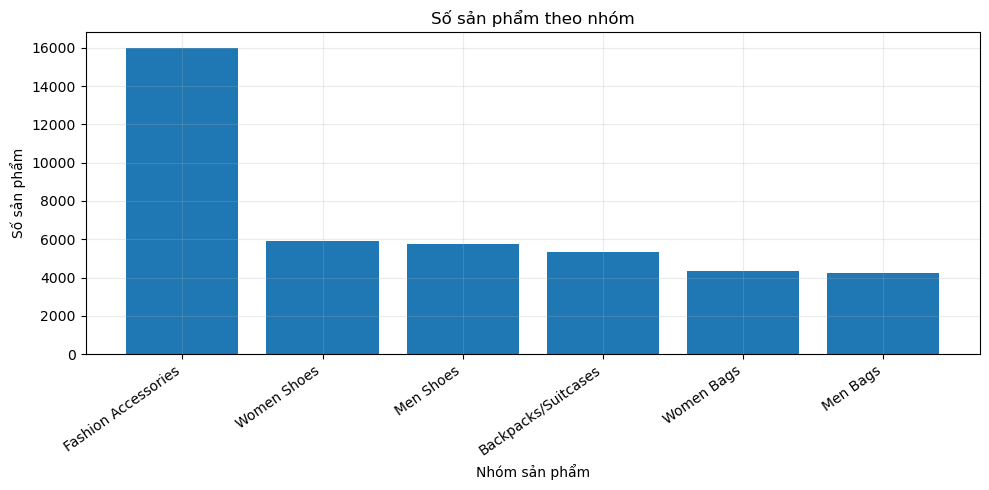

In [7]:
groups, counts = np.unique(products["product_group"].astype(str), return_counts=True)
order = np.argsort(counts)[::-1]
groups = groups[order]
counts = counts[order]

plt.figure(figsize=(10, 5))
plt.bar(groups, counts)
plt.title("Số sản phẩm theo nhóm")
plt.xlabel("Nhóm sản phẩm")
plt.ylabel("Số sản phẩm")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


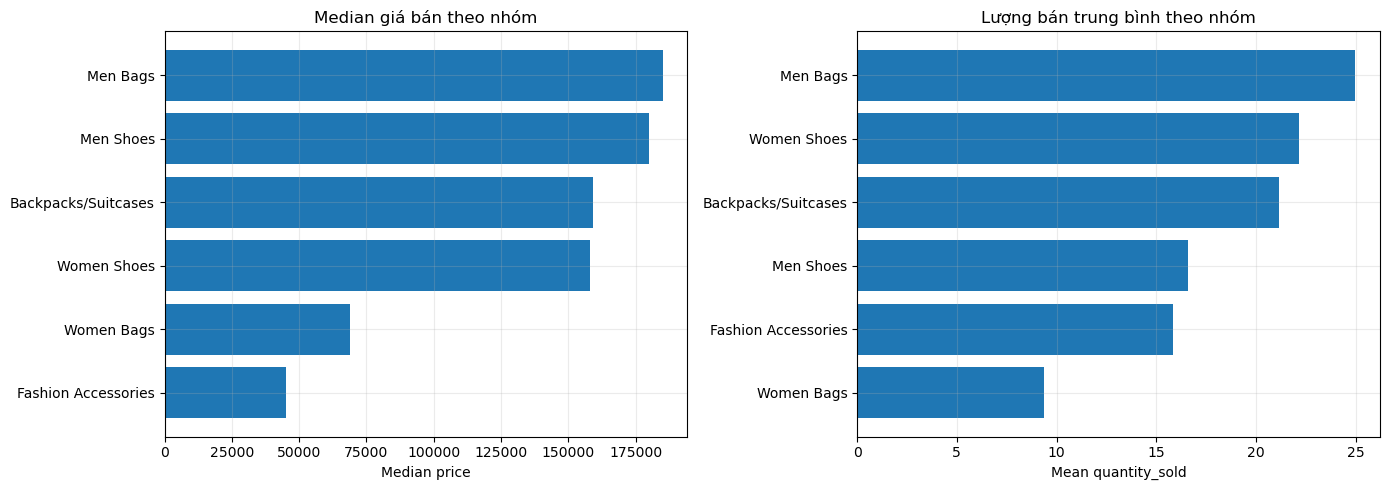

In [8]:
groups = np.array([row["product_group"] for row in rq1_table], dtype=object)
median_prices = np.array([row["median_price"] for row in rq1_table], dtype=float)
mean_sold = np.array([row["mean_sold"] for row in rq1_table], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

price_order = np.argsort(median_prices)
axes[0].barh(groups[price_order], median_prices[price_order])
axes[0].set_title("Median giá bán theo nhóm")
axes[0].set_xlabel("Median price")
axes[0].set_ylabel("")

sold_order = np.argsort(mean_sold)
axes[1].barh(groups[sold_order], mean_sold[sold_order])
axes[1].set_title("Lượng bán trung bình theo nhóm")
axes[1].set_xlabel("Mean quantity_sold")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


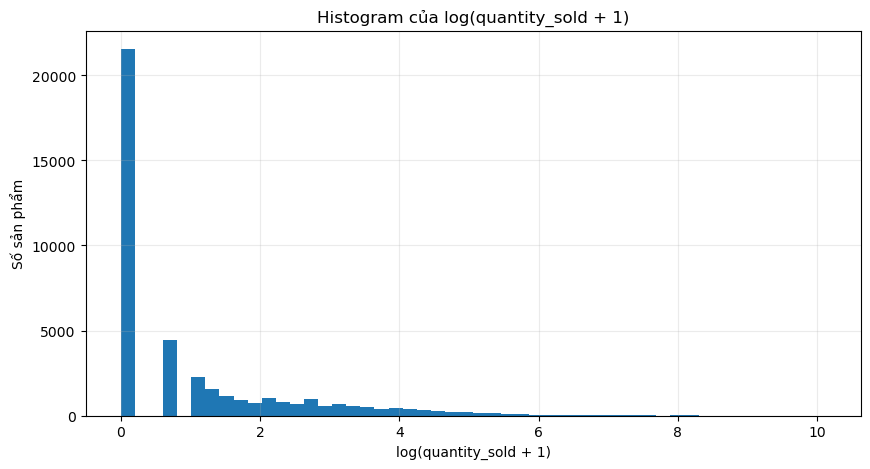

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(products["log_quantity_sold"], bins=50)
plt.title("Histogram của log(quantity_sold + 1)")
plt.xlabel("log(quantity_sold + 1)")
plt.ylabel("Số sản phẩm")
plt.show()


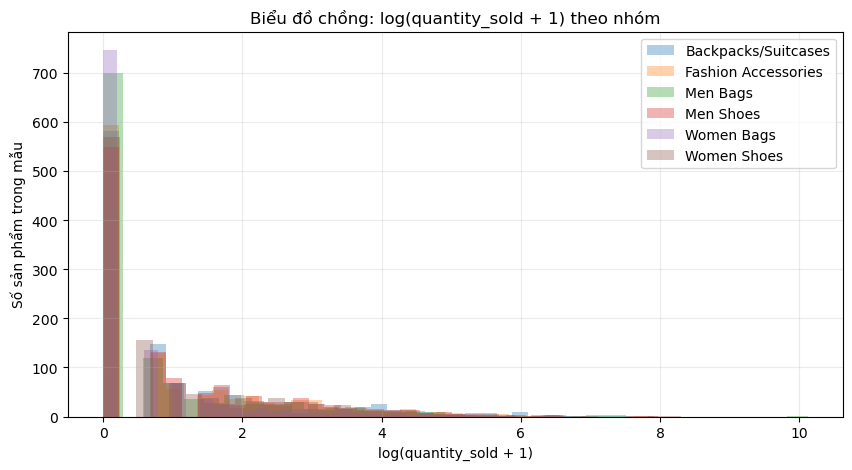

In [10]:
plt.figure(figsize=(10, 5))
product_groups = unique_preserve_order(products["product_group"])
for group in product_groups:
    subset = products["log_quantity_sold"][products["product_group"].astype(str) == str(group)]
    sample_n = min(1200, len(subset))
    if sample_n == 0:
        continue
    sample_idx = rng.choice(np.arange(len(subset)), size=sample_n, replace=False)
    plt.hist(subset[sample_idx], bins=35, alpha=0.35, label=str(group))

plt.title("Biểu đồ chồng: log(quantity_sold + 1) theo nhóm")
plt.xlabel("log(quantity_sold + 1)")
plt.ylabel("Số sản phẩm trong mẫu")
plt.legend()
plt.show()


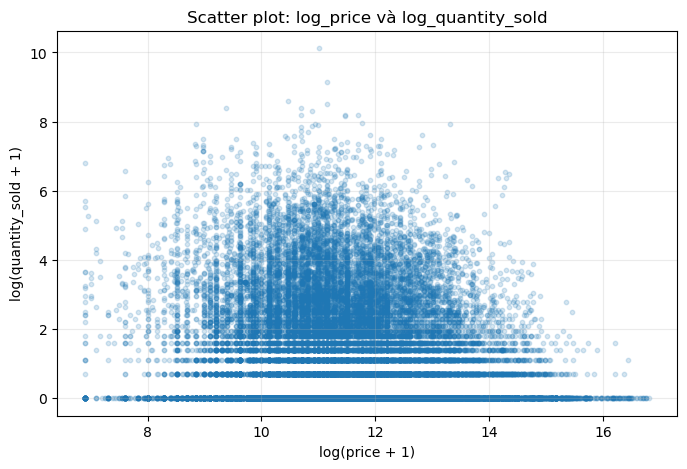

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(products["log_price"], products["log_quantity_sold"], alpha=0.18, s=10)
plt.title("Scatter plot: log_price và log_quantity_sold")
plt.xlabel("log(price + 1)")
plt.ylabel("log(quantity_sold + 1)")
plt.show()


## Trả lời RQ1

Từ bảng và biểu đồ, ta có thể so sánh các nhóm sản phẩm theo giá bán, rating, review count, số ảnh, tỷ lệ video và lượng bán. Vì phân phối lượng bán lệch phải và có nhiều sản phẩm chưa bán được, cần đọc cả `mean_sold` và `median_sold`. `total_sold` cũng cần đọc cùng `n_products`, vì nhóm có nhiều sản phẩm hơn thường có tổng lượng bán lớn hơn.

# 5. Lấy mẫu, empirical distribution và Central Limit Theorem

Một thống kê như trung bình có thể thay đổi nếu ta lấy một mẫu khác. Cell dưới đây lấy nhiều mẫu ngẫu nhiên cùng kích thước và vẽ empirical distribution của sample mean. Đây là cách mô phỏng để hiểu vai trò của ngẫu nhiên và ý tưởng của Central Limit Theorem.

Mean của toàn bộ dữ liệu: 17.777294046903187
Mean của các sample means: 17.853816
SD của các sample means: 6.990343270843891
SD / sqrt(sample_size): 7.530245132957325


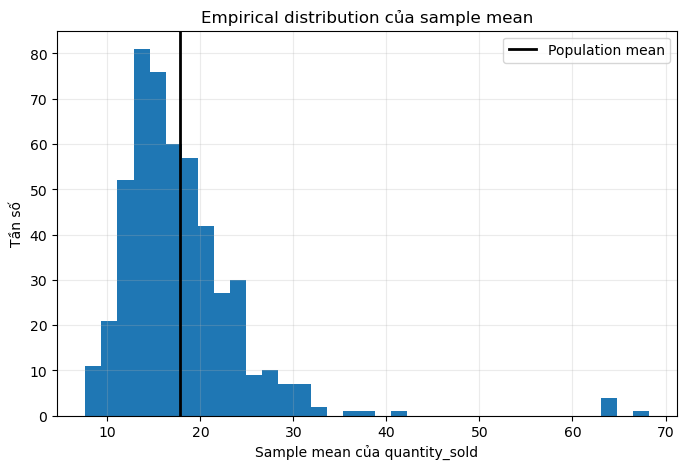

In [12]:
sample_size = min(500, n_rows(products))
repetitions = 500
sample_means = []
quantity_sold = products["quantity_sold"]

for _ in range(repetitions):
    sample_idx = rng.choice(np.arange(n_rows(products)), size=sample_size, replace=False)
    sample_means.append(quantity_sold[sample_idx].mean())

sample_means = np.array(sample_means)

population_mean = quantity_sold.mean()
population_sd = quantity_sold.std(ddof=1)
expected_sd_of_mean = population_sd / np.sqrt(sample_size)

print("Mean của toàn bộ dữ liệu:", population_mean)
print("Mean của các sample means:", sample_means.mean())
print("SD của các sample means:", sample_means.std(ddof=1))
print("SD / sqrt(sample_size):", expected_sd_of_mean)

plt.figure(figsize=(8, 5))
plt.hist(sample_means, bins=35)
plt.axvline(population_mean, color="black", linewidth=2, label="Population mean")
plt.title("Empirical distribution của sample mean")
plt.xlabel("Sample mean của quantity_sold")
plt.ylabel("Tần số")
plt.legend()
plt.show()


# 6. RQ2 — Sản phẩm có video có bán tốt hơn không?

Ta so sánh hai nhóm:

- Sản phẩm có video.
- Sản phẩm không có video.

Thống kê kiểm định là chênh lệch trung bình:

`mean(quantity_sold của nhóm có video) - mean(quantity_sold của nhóm không có video)`.

In [13]:
video_table = []
for label in [False, True]:
    mask = products["has_video"] == label
    video_table.append({
        "has_video": label,
        "n_products": int(mask.sum()),
        "mean_sold": products["quantity_sold"][mask].mean(),
        "median_sold": np.median(products["quantity_sold"][mask]),
        "mean_log_sold": products["log_quantity_sold"][mask].mean(),
        "mean_price": products["price"][mask].mean(),
        "mean_reviews": products["review_count"][mask].mean(),
    })

display_table(video_table, columns=[
    "has_video", "n_products", "mean_sold", "median_sold",
    "mean_log_sold", "mean_price", "mean_reviews"
])

observed_difference = (
    products["quantity_sold"][products["has_video"]].mean()
    - products["quantity_sold"][~products["has_video"]].mean()
)
print("Chênh lệch trung bình quan sát được:", observed_difference)


| has_video | n_products | mean_sold | median_sold | mean_log_sold | mean_price | mean_reviews |
| --- | --- | --- | --- | --- | --- | --- |
| False | 37304 | 15.883 | 0.000 | 0.966 | 267,499.451 | 2.613 |
| True | 4271 | 34.321 | 3.000 | 1.721 | 314,866.122 | 7.474 |

Chênh lệch trung bình quan sát được: 18.437826040325128


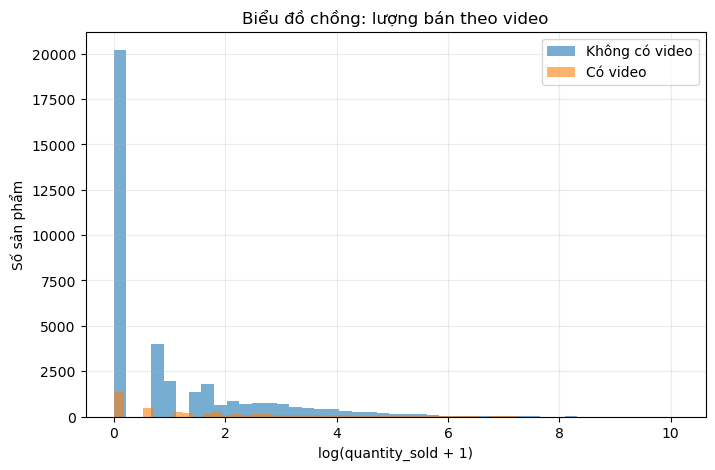

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(
    products["log_quantity_sold"][~products["has_video"]],
    bins=45,
    alpha=0.6,
    label="Không có video",
)
plt.hist(
    products["log_quantity_sold"][products["has_video"]],
    bins=45,
    alpha=0.6,
    label="Có video",
)
plt.title("Biểu đồ chồng: lượng bán theo video")
plt.xlabel("log(quantity_sold + 1)")
plt.ylabel("Số sản phẩm")
plt.legend()
plt.show()


## 6.1 Kiểm định giả thuyết bằng permutation test

**Null hypothesis:** Video không liên quan đến lượng bán. Nếu đúng như vậy, ta có thể tráo ngẫu nhiên nhãn có video/không video giữa các sản phẩm.

**Alternative hypothesis:** Sản phẩm có video có lượng bán trung bình cao hơn sản phẩm không có video.

Ta mô phỏng nhiều lần theo null hypothesis bằng cách shuffle nhãn `has_video`.

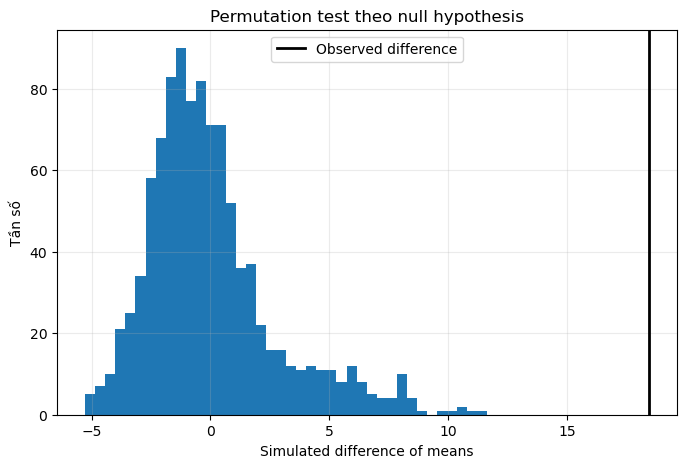

Observed difference: 18.437826040325128
p-value <  0.001


In [15]:
def difference_of_means(values, labels):
    labels = np.asarray(labels).astype(bool)
    values = np.asarray(values)
    return values[labels].mean() - values[~labels].mean()

values = products["quantity_sold"]
labels = products["has_video"]

n_simulations = 1000
simulated_differences = []

for _ in range(n_simulations):
    shuffled_labels = rng.permutation(labels)
    one_difference = difference_of_means(values, shuffled_labels)
    simulated_differences.append(one_difference)

simulated_differences = np.array(simulated_differences)
p_value = np.mean(simulated_differences >= observed_difference)

plt.figure(figsize=(8, 5))
plt.hist(simulated_differences, bins=40)
plt.axvline(observed_difference, color="black", linewidth=2, label="Observed difference")
plt.title("Permutation test theo null hypothesis")
plt.xlabel("Simulated difference of means")
plt.ylabel("Tần số")
plt.legend()
plt.show()

print("Observed difference:", observed_difference)
if p_value == 0:
    print("p-value < ", 1 / n_simulations)
else:
    print("p-value:", p_value)


## 6.2 Bootstrap confidence interval

Sau kiểm định giả thuyết, ta dùng bootstrap để ước lượng khoảng tin cậy cho chênh lệch trung bình. Bootstrap lấy mẫu lại có hoàn lại từ từng nhóm và tính lại chênh lệch trung bình nhiều lần.

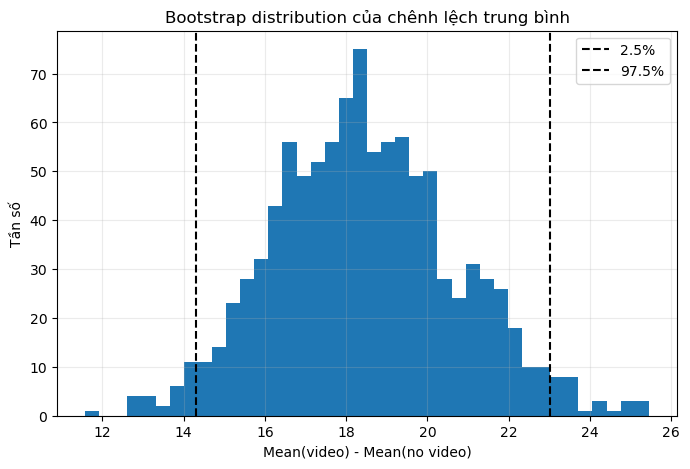

95% bootstrap confidence interval: (14.307126881457885, 23.023922242672892)


In [16]:
video_sold = products["quantity_sold"][products["has_video"]]
no_video_sold = products["quantity_sold"][~products["has_video"]]

bootstrap_differences = []
for _ in range(1000):
    video_sample = rng.choice(video_sold, size=len(video_sold), replace=True)
    no_video_sample = rng.choice(no_video_sold, size=len(no_video_sold), replace=True)
    bootstrap_differences.append(video_sample.mean() - no_video_sample.mean())

bootstrap_differences = np.array(bootstrap_differences)
ci_low, ci_high = np.percentile(bootstrap_differences, [2.5, 97.5])

plt.figure(figsize=(8, 5))
plt.hist(bootstrap_differences, bins=40)
plt.axvline(ci_low, color="black", linestyle="--", label="2.5%")
plt.axvline(ci_high, color="black", linestyle="--", label="97.5%")
plt.title("Bootstrap distribution của chênh lệch trung bình")
plt.xlabel("Mean(video) - Mean(no video)")
plt.ylabel("Tần số")
plt.legend()
plt.show()

print("95% bootstrap confidence interval:", (float(ci_low), float(ci_high)))


## Trả lời RQ2

Nếu p-value nhỏ và khoảng tin cậy bootstrap không chứa 0, dữ liệu cho thấy sản phẩm có video có lượng bán trung bình cao hơn sản phẩm không có video. Tuy nhiên, đây là dữ liệu quan sát, nên ta chỉ kết luận có sự khác biệt/liên hệ thống kê, không kết luận video chắc chắn là nguyên nhân làm tăng lượng bán.

# 7. RQ3 — Những đặc trưng nào liên quan đến nhu cầu sản phẩm?

## 7.1. Giới thiệu RQ3

RQ3 nhằm phân tích mối quan hệ giữa các đặc trưng của sản phẩm và nhu cầu thị trường. Để thực hiện điều này ta cần xây dựng mô hình hồi quy tuyến tính bội với biến mục tiêu là `log_quantity_sold`.

Việc sử dụng log transformation giúp giảm ảnh hưởng của các sản phẩm có doanh số quá lớn và làm cho dữ liệu phù hợp hơn với mô hình hồi quy tuyến tính.

Biến mục tiêu:

`log_quantity_sold = log(quantity_sold + 1)`

Các đặc trưng được xem xét gồm giá bán, tỷ lệ giảm giá, rating, số lượt đánh giá, số lượt yêu thích, số ảnh và video.

In [17]:
# Tạo các biến đúng theo yêu cầu của RQ3.
products = copy_table(products)

products["favourite_count"] = np.nan_to_num(products["favourite_count"], nan=0.0)
##products["log_favourite_count"] = np.log1p(products["favourite_count"])
##products["images_count"] = products["number_of_images"].copy()
products["video_count"] = products["has_video_int"].copy()

target_var = "log_quantity_sold"
model_features = [
    "log_price",
    "discount_rate",
    "rating_average",
    "log_review_count",
   ## "log_favourite_count",
    ##"images_count",
    "video_count",
]

rq3_columns = [target_var] + model_features
rq3_data = {col: products[col].astype(float) for col in rq3_columns}
valid_rq3 = np.ones(n_rows(rq3_data), dtype=bool)
for col in rq3_columns:
    valid_rq3 &= np.isfinite(rq3_data[col])
rq3_data = take_rows(rq3_data, valid_rq3)

print("Số dòng dùng cho RQ3:", n_rows(rq3_data))
display_table(head_records(rq3_data, 5, rq3_columns))


Số dòng dùng cho RQ3: 41575


| log_quantity_sold | log_price | discount_rate | rating_average | log_review_count | video_count |
| --- | --- | --- | --- | --- | --- |
| 0.000 | 9.565 | 0.000 | 0.000 | 0.000 | 0.000 |
| 0.000 | 9.236 | 0.000 | 0.000 | 0.000 | 0.000 |
| 0.000 | 9.903 | 0.000 | 0.000 | 0.000 | 0.000 |
| 0.000 | 10.309 | 0.000 | 0.000 | 0.000 | 0.000 |
| 0.000 | 10.275 | 0.000 | 0.000 | 0.000 | 0.000 |

## 7.2. Correlation Analysis

Mục tiêu của phần này là khám phá mối quan hệ ban đầu giữa các biến trước khi xây dựng mô hình. Ta tạo correlation matrix cho:

- `log_quantity_sold`
- `log_price`
- `discount_rate`
- `rating_average`
- `log_review_count`
- `images_count`
- `video_count`

Sau đó vẽ heatmap để dễ quan sát biến nào có tương quan mạnh hoặc yếu với demand.

| variable | log_quantity_sold | log_price | discount_rate | rating_average | log_review_count | video_count |
| --- | --- | --- | --- | --- | --- | --- |
| log_quantity_sold | 1.000 | -0.108 | 0.177 | 0.744 | 0.886 | 0.158 |
| log_price | -0.108 | 1.000 | 0.109 | -0.011 | -0.022 | 0.061 |
| discount_rate | 0.177 | 0.109 | 1.000 | 0.171 | 0.184 | 0.180 |
| rating_average | 0.744 | -0.011 | 0.171 | 1.000 | 0.785 | 0.155 |
| log_review_count | 0.886 | -0.022 | 0.184 | 0.785 | 1.000 | 0.160 |
| video_count | 0.158 | 0.061 | 0.180 | 0.155 | 0.160 | 1.000 |

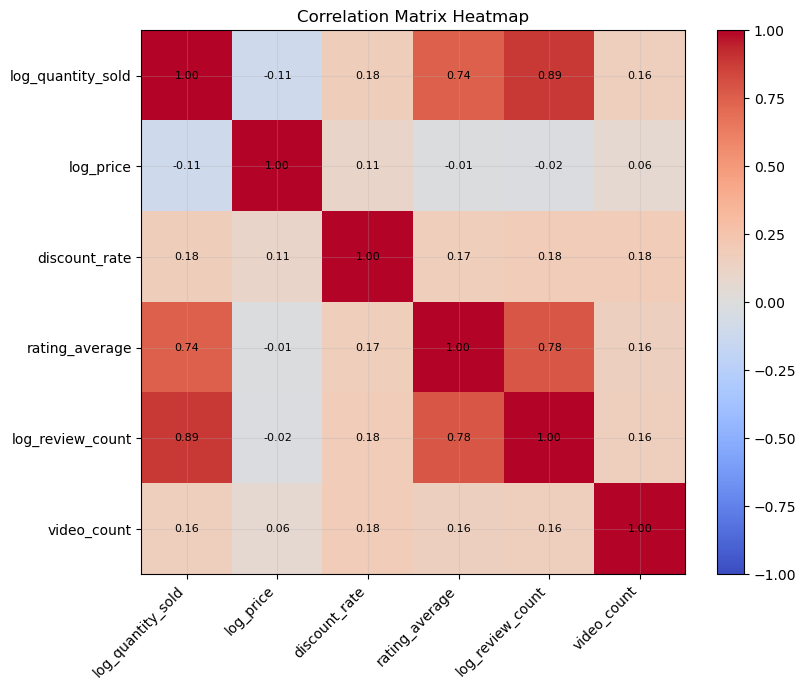

In [18]:
corr_vars = [target_var] + model_features
corr_input = np.column_stack([rq3_data[var] for var in corr_vars])
corr_matrix = np.corrcoef(corr_input, rowvar=False)

corr_records = []
for i, row_name in enumerate(corr_vars):
    row = {"variable": row_name}
    for j, col_name in enumerate(corr_vars):
        row[col_name] = corr_matrix[i, j]
    corr_records.append(row)
display_table(corr_records, columns=["variable"] + corr_vars)

fig, ax = plt.subplots(figsize=(9, 7))
corr_for_plot = np.nan_to_num(corr_matrix, nan=0.0)
image = ax.imshow(corr_for_plot, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(corr_vars)))
ax.set_yticks(np.arange(len(corr_vars)))
ax.set_xticklabels(corr_vars, rotation=45, ha="right")
ax.set_yticklabels(corr_vars)

for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        value = corr_for_plot[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()


In [19]:
demand_correlations = corr_matrix[0, 1:]
order = np.argsort(np.abs(demand_correlations))[::-1]

correlation_rows = [
    {
        "Feature": model_features[i],
        "correlation_with_demand(log_quantity_sold)": demand_correlations[i],
    }
    for i in order
]

print("Tương quan với demand, sắp xếp theo độ lớn tuyệt đối:")
display_table(correlation_rows, columns=["Feature", "correlation_with_demand(log_quantity_sold)"])

strongest_idx = order[0]
strongest_feature = model_features[strongest_idx]
strongest_value = demand_correlations[strongest_idx]
weakest_idx = int(np.argmin(np.abs(demand_correlations)))
weakest_feature = model_features[weakest_idx]
weakest_value = demand_correlations[weakest_idx]

print("Biến tương quan mạnh nhất với demand:", strongest_feature, "=", round(float(strongest_value), 3))
print("Biến tương quan yếu nhất với demand:", weakest_feature, "=", round(float(weakest_value), 3))

high_pairs = []
for i, left in enumerate(model_features):
    left_pos = corr_vars.index(left)
    for right in model_features[i + 1:]:
        right_pos = corr_vars.index(right)
        value = corr_matrix[left_pos, right_pos]
        if np.isfinite(value) and abs(value) >= 0.70:
            high_pairs.append((left, right, value))

if high_pairs:
    print("Các cặp feature có tương quan cao với nhau:")
    for left, right, value in high_pairs:
        print(f"- {left} và {right}: {value:.3f}")
else:
    print("Không có cặp feature nào có |correlation| >= 0.70.")


Tương quan với demand, sắp xếp theo độ lớn tuyệt đối:


| Feature | correlation_with_demand(log_quantity_sold) |
| --- | --- |
| log_review_count | 0.886 |
| rating_average | 0.744 |
| discount_rate | 0.177 |
| video_count | 0.158 |
| log_price | -0.108 |

Biến tương quan mạnh nhất với demand: log_review_count = 0.886
Biến tương quan yếu nhất với demand: log_price = -0.108
Các cặp feature có tương quan cao với nhau:
- rating_average và log_review_count: 0.785


**Diễn giải correlation.** `log_review_count` thường là biến có tương quan dương mạnh nhất với demand, cho thấy sản phẩm có nhiều lượt đánh giá thường có lượng bán cao hơn. `log_price` có tương quan âm với demand, nghĩa là sản phẩm giá cao thường có lượng bán thấp hơn. Một số biến như `images_count` hoặc `video_count` có tương quan dương nhưng yếu hơn. Nếu `log_favourite_count` có giá trị NaN hoặc gần 0, lý do là cột `favourite_count` trong dữ liệu hầu như không có biến thiên.

## 7.3. Multiple Linear Regression

Mục tiêu của phần này là xác định ảnh hưởng đồng thời của nhiều biến lên demand.

**Features X:**

- `log_price`
- `discount_rate`
- `rating_average`
- `log_review_count`
- `log_favourite_count`
- `images_count`
- `video_count`

**Target y:**

- `log_quantity_sold`

Ta chia dữ liệu thành training set và test set, sau đó fit mô hình hồi quy tuyến tính bội bằng phương pháp least squares.

In [20]:
X_raw = np.column_stack([rq3_data[feature] for feature in model_features])
y = rq3_data[target_var]

indices = rng.permutation(n_rows(rq3_data))
train_size = int(0.8 * n_rows(rq3_data))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train_raw = X_raw[train_idx]
X_test_raw = X_raw[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

# Chuẩn hóa feature để coefficient có thể so sánh tương đối.
feature_means = X_train_raw.mean(axis=0)
feature_stds = X_train_raw.std(axis=0)
constant_features = [model_features[i] for i, sd in enumerate(feature_stds) if sd == 0]
feature_stds[feature_stds == 0] = 1

X_train = (X_train_raw - feature_means) / feature_stds
X_test = (X_test_raw - feature_means) / feature_stds

def add_intercept(X):
    return np.column_stack([np.ones(len(X)), X])

X_train_design = add_intercept(X_train)
X_test_design = add_intercept(X_test)

coefficients = np.linalg.lstsq(X_train_design, y_train, rcond=None)[0]
y_pred = X_test_design @ coefficients

print("Train size:", len(X_train_design))
print("Test size:", len(X_test_design))
if constant_features:
    print("Feature không có biến thiên trong training set:", constant_features)


Train size: 33260
Test size: 8315


## 7.4. Model Evaluation

Ta đánh giá mô hình bằng:

- **RMSE:** sai số bình phương trung bình căn bậc hai.
- **MAE:** sai số tuyệt đối trung bình.
- **R²:** tỷ lệ biến thiên của demand được mô hình giải thích.

Ví dụ, nếu `R² = 0.65`, điều đó có nghĩa mô hình giải thích được khoảng 65% biến thiên của nhu cầu sản phẩm.

In [21]:
residuals = y_test - y_pred

rmse = np.sqrt(np.mean(residuals ** 2))
mae = np.mean(np.abs(residuals))
r_squared = 1 - np.sum(residuals ** 2) / np.sum((y_test - y_test.mean()) ** 2)

evaluation_table = [
    {"Metric": "RMSE", "Value": rmse},
    {"Metric": "MAE", "Value": mae},
    {"Metric": "R²", "Value": r_squared},
]

display_table(evaluation_table, columns=["Metric", "Value"], precision=4)
print(f"R² = {r_squared:.3f}, nghĩa là mô hình giải thích khoảng {r_squared * 100:.1f}% biến thiên của log_quantity_sold trên test set.")


| Metric | Value |
| --- | --- |
| RMSE | 0.6483 |
| MAE | 0.4776 |
| R² | 0.8002 |

R² = 0.800, nghĩa là mô hình giải thích khoảng 80.0% biến thiên của log_quantity_sold trên test set.


## 7.5. Residual Analysis

Residual được tính bằng:

`Residual = Actual - Predicted`

Nếu residual phân bố ngẫu nhiên quanh 0 và không có xu hướng rõ rệt, mô hình phù hợp tương đối tốt. Nếu residual có pattern rõ rệt, mô hình có thể đang bỏ sót một quan hệ quan trọng hoặc quan hệ không tuyến tính.

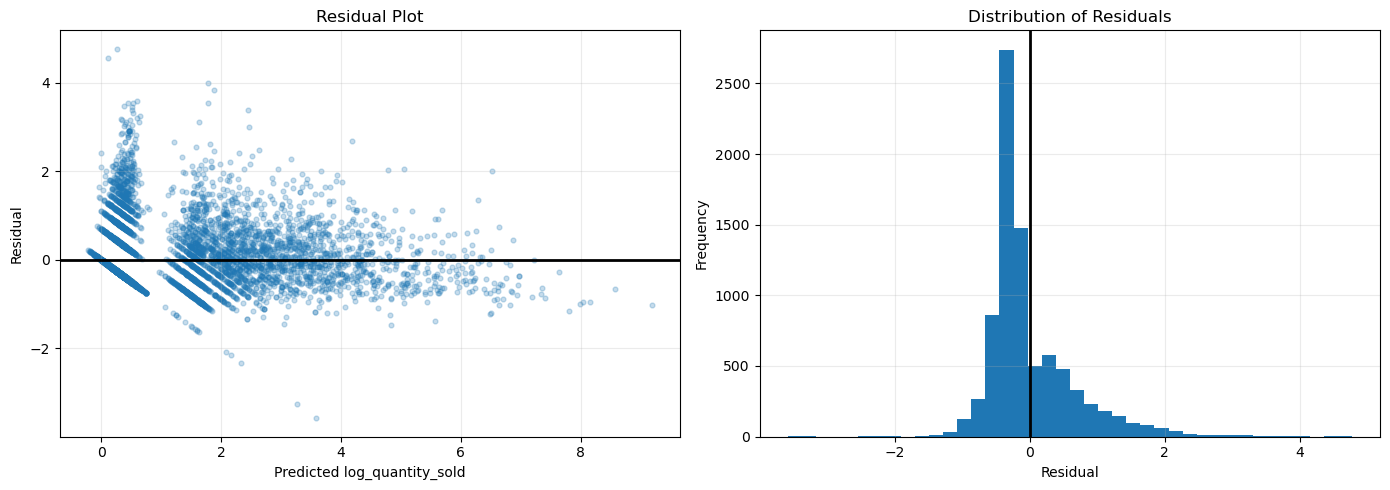

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.25, s=12)
axes[0].axhline(0, color="black", linewidth=2)
axes[0].set_title("Residual Plot")
axes[0].set_xlabel("Predicted log_quantity_sold")
axes[0].set_ylabel("Residual")

axes[1].hist(residuals, bins=40)
axes[1].axvline(0, color="black", linewidth=2)
axes[1].set_title("Distribution of Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


**Diễn giải residual.** Residual plot cho biết mô hình có dự đoán lệch theo một xu hướng rõ rệt hay không. Nếu phần lớn điểm nằm quanh đường 0 và không tạo thành pattern mạnh, mô hình tuyến tính bội có thể xem là phù hợp tương đối. Nếu có nhiều outlier hoặc residual mở rộng ở một vùng dự đoán, điều đó cho thấy demand vẫn còn chịu ảnh hưởng bởi các yếu tố chưa có trong dữ liệu.

## 7.6. Coefficient Interpretation

Vì các feature đã được chuẩn hóa trước khi fit mô hình, coefficient có thể được so sánh tương đối với nhau. Coefficient dương nghĩa là khi feature tăng, demand dự đoán tăng. Coefficient âm nghĩa là khi feature tăng, demand dự đoán giảm.

In [23]:
coefficient_table = [
    {
        "Feature": feature,
        "Coefficient": coef,
        "Abs Coefficient": abs(coef),
    }
    for feature, coef in zip(model_features, coefficients[1:])
]
coefficient_table = sorted(coefficient_table, key=lambda row: row["Abs Coefficient"], reverse=True)

display_table(coefficient_table, columns=["Feature", "Coefficient", "Abs Coefficient"], precision=4)


| Feature | Coefficient | Abs Coefficient |
| --- | --- | --- |
| log_review_count | 1.1376 | 1.1376 |
| rating_average | 0.1778 | 0.1778 |
| log_price | -0.1347 | 0.1347 |
| discount_rate | 0.0310 | 0.0310 |
| video_count | 0.0255 | 0.0255 |

**Nhận xét về coefficient.**

- `log_review_count` là biến có ảnh hưởng mạnh nhất và có hệ số dương. Điều này phù hợp với trực giác: sản phẩm có nhiều đánh giá thường là sản phẩm đã có nhiều tương tác và thường bán tốt hơn.
- `log_price` có hệ số âm, cho thấy giá bán cao hơn có liên quan đến demand thấp hơn khi các biến khác được xét đồng thời trong mô hình.
- `discount_rate` có hệ số dương, nhưng mức độ ảnh hưởng nhỏ hơn `log_review_count`.
- `video_count` và `images_count` có thể có hệ số dương hoặc nhỏ tùy dữ liệu; điều này cho thấy nội dung hình ảnh/video có liên quan đến demand nhưng không mạnh bằng review count.
- `log_favourite_count` không đóng góp nhiều nếu cột favourite trong dữ liệu không có biến thiên.

## 7.7. Bootstrap Confidence Intervals

Mục tiêu của phần này là kiểm tra độ ổn định của các hệ số hồi quy.

Ta bootstrap cho ba biến chính:

- `log_review_count`
- `log_price`
- `discount_rate`

Nếu confidence interval không chứa 0, ta có bằng chứng cho thấy biến đó thực sự liên quan đến demand. Nếu confidence interval chứa 0, ta chưa đủ bằng chứng để kết luận.

In [24]:
bootstrap_features = ["log_review_count", "log_price", "discount_rate"]
bootstrap_positions = [model_features.index(feature) + 1 for feature in bootstrap_features]

n_bootstrap = 500
bootstrap_coefs = []

for _ in range(n_bootstrap):
    sample_idx = rng.choice(np.arange(len(X_train_design)), size=len(X_train_design), replace=True)
    boot_X = X_train_design[sample_idx]
    boot_y = y_train[sample_idx]
    boot_coef = np.linalg.lstsq(boot_X, boot_y, rcond=None)[0]
    bootstrap_coefs.append(boot_coef[bootstrap_positions])

bootstrap_coefs = np.array(bootstrap_coefs)
ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)

bootstrap_ci_table = [
    {
        "Feature": feature,
        "Coefficient": coefficients[position],
        "CI Lower": low,
        "CI Upper": high,
        "Contains 0?": bool(low <= 0 <= high),
    }
    for feature, position, low, high in zip(
        bootstrap_features,
        bootstrap_positions,
        ci_lower,
        ci_upper,
    )
]

display_table(
    bootstrap_ci_table,
    columns=["Feature", "Coefficient", "CI Lower", "CI Upper", "Contains 0?"],
    precision=4,
)


| Feature | Coefficient | CI Lower | CI Upper | Contains 0? |
| --- | --- | --- | --- | --- |
| log_review_count | 1.1376 | 1.1256 | 1.1494 | False |
| log_price | -0.1347 | -0.1419 | -0.1277 | False |
| discount_rate | 0.0310 | 0.0234 | 0.0389 | False |

**Diễn giải bootstrap CI.**

- Nếu CI của `log_review_count` không chứa 0, có bằng chứng cho thấy review count liên quan ổn định đến demand.
- Nếu CI của `log_price` nằm hoàn toàn dưới 0, có bằng chứng cho thấy giá bán có mối liên hệ âm với demand.
- Nếu CI của `discount_rate` nằm hoàn toàn trên 0, discount rate có mối liên hệ dương với demand. Nếu CI chứa 0, kết quả này chưa đủ ổn định để kết luận mạnh.

## 7.8. Key Findings

1. `Review count` là yếu tố liên quan mạnh nhất đến nhu cầu sản phẩm.

2. Các sản phẩm có nhiều đánh giá thường đạt doanh số cao hơn.

3. Giá bán có mối liên hệ âm với nhu cầu: sản phẩm có giá cao hơn thường có demand thấp hơn.

4. `Discount rate` có mối liên hệ dương nhưng mức độ ảnh hưởng thấp hơn review count.

5. Mô hình hồi quy tuyến tính bội có khả năng giải thích một phần đáng kể sự biến động của demand.

6. Bootstrap confidence intervals giúp xác nhận tính ổn định của các kết quả chính, đặc biệt với `log_review_count`, `log_price` và `discount_rate`.

# 8. Kết luận chung

## RQ1

RQ1 mô tả sự khác biệt giữa các nhóm sản phẩm về giá bán, rating, số lượt đánh giá, số ảnh, video và lượng bán. Đây là bước khám phá dữ liệu, giúp nhận diện xu hướng ban đầu và outlier.

## RQ2

RQ2 tập trung vào câu hỏi sản phẩm có video có bán tốt hơn hay không. Difference of means, permutation test và bootstrap confidence interval cho phép đánh giá sự khác biệt giữa hai nhóm có video và không có video.

## RQ3

RQ3 mở rộng phân tích sang nhiều đặc trưng sản phẩm cùng lúc. Correlation analysis cho thấy quan hệ ban đầu giữa các biến. Multiple linear regression cho phép đánh giá ảnh hưởng đồng thời của giá, discount, rating, review count, favourite count, images và video lên `log_quantity_sold`. Model evaluation, residual analysis, coefficient interpretation và bootstrap CI giúp đánh giá chất lượng mô hình và độ ổn định của kết quả.

# 9. Checklist cấu trúc cuối cùng

**RQ1: Phân tích mô tả dữ liệu và nhu cầu sản phẩm**

- Bảng tổng hợp theo nhóm sản phẩm.
- Biểu đồ mô tả phân phối và so sánh nhóm.

**RQ2: Sản phẩm có video có bán tốt hơn không?**

- Difference of Means.
- Permutation Test.
- Bootstrap CI.
- Conclusion.

**RQ3: Những đặc trưng nào liên quan đến nhu cầu sản phẩm?**

- Correlation Analysis.
- Multiple Linear Regression.
- Model Evaluation.
- Residual Analysis.
- Coefficient Interpretation.
- Bootstrap CI.
- Key Findings.

Cấu trúc này giúp mỗi RQ trả lời một câu hỏi riêng biệt, tránh chồng chéo và tạo luồng phân tích rõ ràng, phù hợp với yêu cầu của một đồ án môn Khoa học Dữ liệu.